<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees


 **Decision Tree - Summary**

> A **Decision Tree** is a supervised machine learning algorithm that makes predictions by repeatedly splitting the dataset into smaller groups based on the most informative feature. The goal is to increase the **purity** of each node until the data in a node belongs to a single class or a stopping condition is reached.

 **How it works**

1. Choose the **root node**.
2. Evaluate all features and select the one that gives the **highest Information Gain**.
3. Split the data into branches based on that feature.
4. Repeat the process recursively for each branch.
5. Stop splitting when a node is sufficiently pure (or another stopping criterion such as `max_depth` is reached).

 **Entropy**

* Entropy measures the **impurity** (or disorder) of a node.
* Lower entropy means the node is purer.
* A completely pure node has **Entropy = 0**.

 **Information Gain**

Information Gain measures how much impurity is reduced after a split.

[
\text{Information Gain} = H(\text{Parent}) - \left(w_{left}H_{left} + w_{right}H_{right}\right)
]

where:

* (H) = Entropy
* (w) = Fraction of samples in each child node

The feature with the **highest Information Gain** is chosen for the split.

 **One-Hot Encoding**

If a feature is **categorical** (e.g., Color = Red, Blue, Green), it cannot be used directly by many ML algorithms. **One-Hot Encoding** converts each category into a separate binary (0/1) column.

Example:

| Color | Red | Blue | Green |
| ----- | :-: | :--: | :---: |
| Red   |  1  |   0  |   0   |
| Blue  |  0  |   1  |   0   |
| Green |  0  |   0  |   1   |

Only one column is **1** for each sample.

 **Effect of Tree Depth**

* A **small `max_depth`** means the tree can ask only a few questions, so it uses only the most informative features.
* A **larger `max_depth`** allows the tree to make more splits, use additional features, and fit the training data better.
* If the depth becomes too large, the tree may **overfit** by memorizing the training data instead of learning general patterns.


## Load data: Iris Dataset

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
X=iris.data
y=iris.target

print(X.shape)
print(iris.feature_names)
print(iris.target_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


## Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Create the Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion = "entropy" ,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

> criterion = "entropy" : Use Information Gain (Entropy) to choose the best split.

U can use  ```criterion = "entropy"``` which is another impurity measure.

## Train

In [6]:
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [7]:
y_pred=model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

1.0  because Iris is a relatively easy dataset.

Notice that, we didn't compile it separately! Sklearn libs already know how to compile when we create model with    ```DecisionTreeClassifier```

## Visualize the Tree

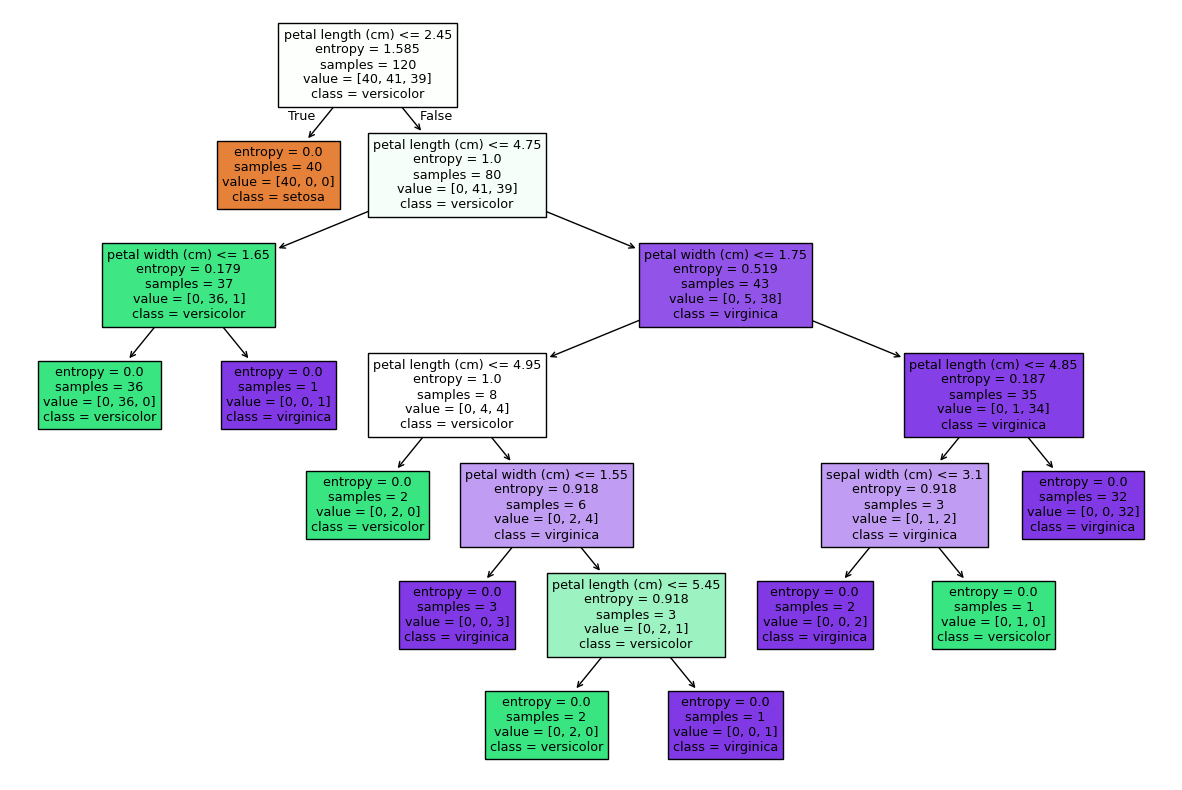

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

## Make predictions

In [18]:
y_pred = model.predict(X_test)

## Evaluation:

### Accuracy (most common evaluation criteria)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6333333333333333


### Confusion Matrix (recommended)

In [20]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0 11  0]]


### Classification Report (recommended)

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.45      1.00      0.62         9
           2       0.00      0.00      0.00        11

    accuracy                           0.63        30
   macro avg       0.48      0.67      0.54        30
weighted avg       0.47      0.63      0.52        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Compare Training vs Testing Accuracy

In [22]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.675
Testing Accuracy: 0.6333333333333333


## Changing Depth of the tree to see accuracy:

max_depth=1

0.6333333333333333


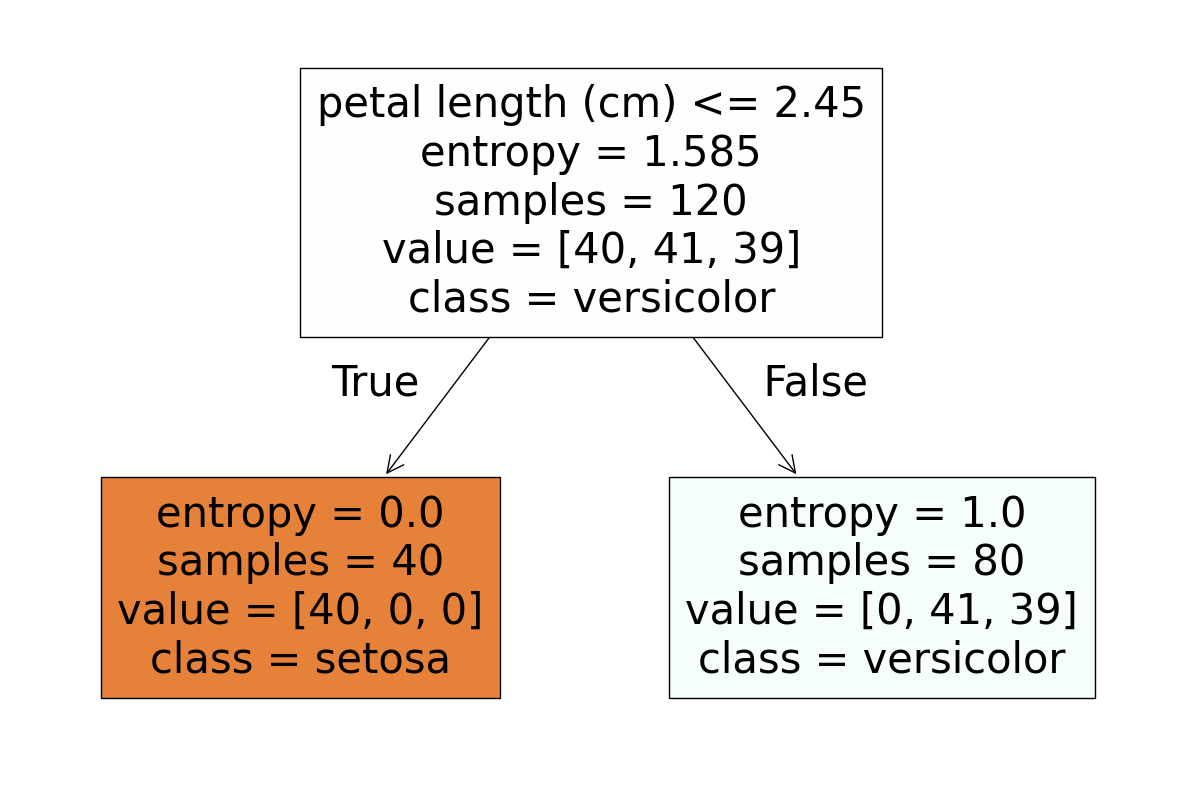

sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 1.0
petal width (cm) : 0.0


In [17]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion = "entropy", max_depth=1, random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(accuracy_score(y_test,y_pred))
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()
for feature, importance in zip(iris.feature_names, model.feature_importances_):
    print(feature, ":", importance)

max_depth=5

1.0


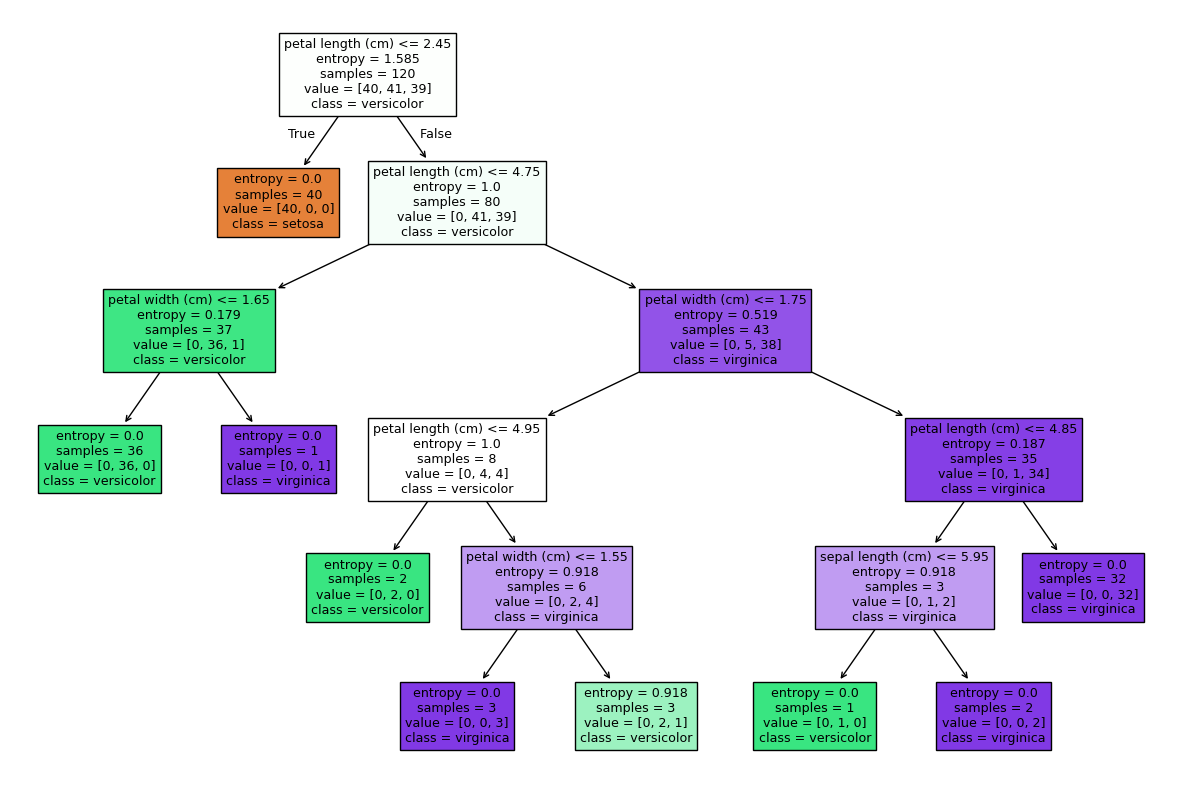

sepal length (cm) : 0.014700217405844837
sepal width (cm) : 0.0
petal length (cm) : 0.8938682125679738
petal width (cm) : 0.09143157002618146


In [16]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion = "entropy", max_depth=5, random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(accuracy_score(y_test,y_pred))
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()
for feature, importance in zip(iris.feature_names, model.feature_importances_):
    print(feature, ":", importance)

max_depth=3

1.0


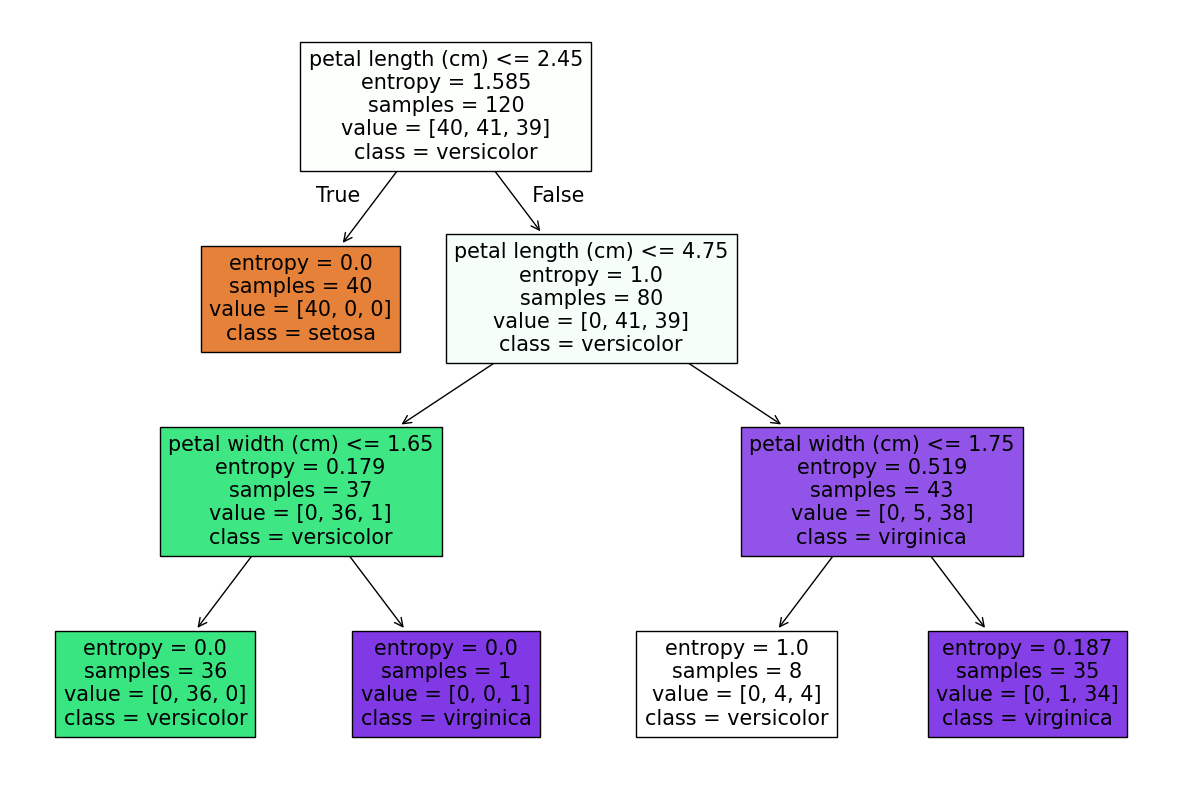

sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 0.9181143076311176
petal width (cm) : 0.0818856923688824


In [15]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion = "entropy", max_depth=3, random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(accuracy_score(y_test,y_pred))
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()
for feature, importance in zip(iris.feature_names, model.feature_importances_):
    print(feature, ":", importance)

> A shallow tree has fewer chances to split, so it relies on only the most informative features. A deeper tree can continue splitting each branch, allowing it to use additional features to further reduce impurity.

## OverFitting V/S UnderFitting

If u have under-fitting, just increase the max depth, performance most likely to get better.

If u get Over-Fitting : Model Memorizing examples, decrease the depth of the tree and also add:
```
    min_samples_split=10,
    min_samples_leaf=5,
```


**min_samples_split :** if a node has less than 10 examples, model won't split it.

**min_samples_leaf :** if after split, new branch has less than 5 leaf, model won't split.

These are hyperparameters. You don't memorize values like 5, 8, or 10—they depend on the dataset. In practice, you try different combinations (or use techniques like cross-validation or grid search later in your ML journey) to find what generalizes best.



## Using Gini Algo instead of Entropy

In [23]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(X_train, y_train)
model.predict(X_test)
accuracy_score(y_test, y_pred)

0.6333333333333333

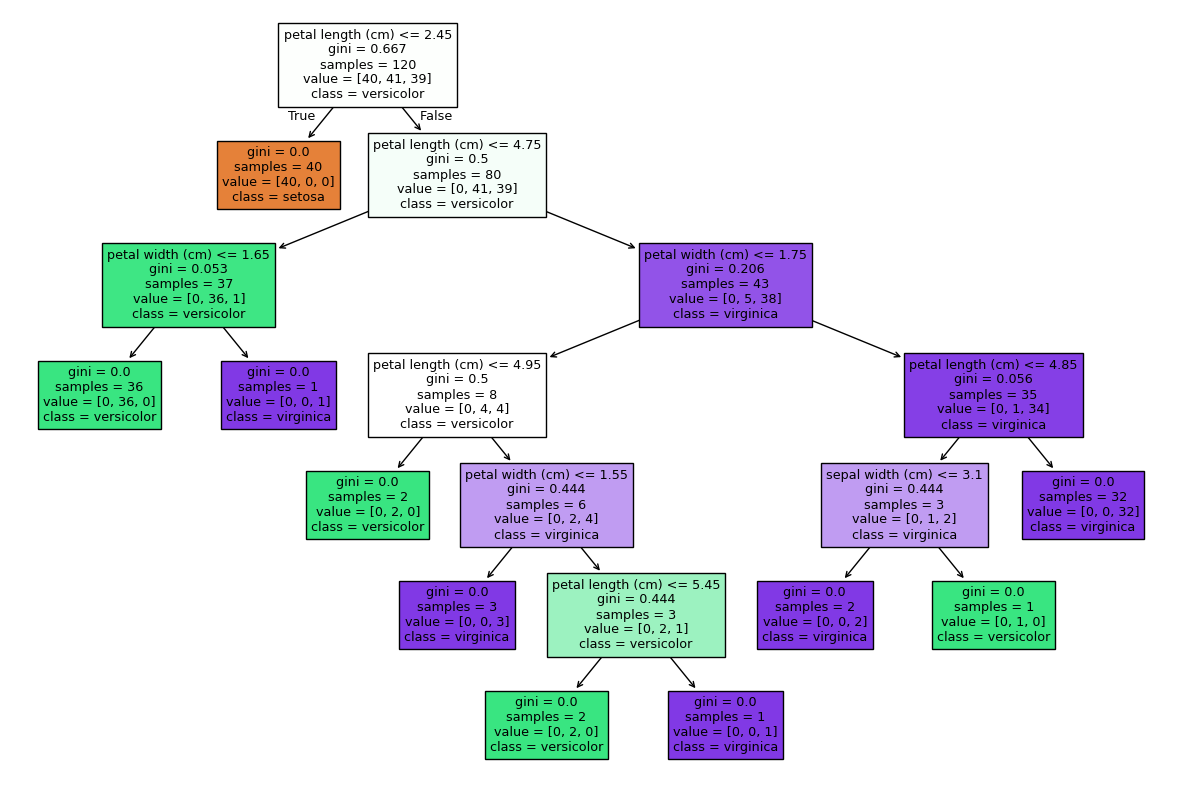

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

In [25]:
entropy_tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
gini_tree = DecisionTreeClassifier(criterion="gini", random_state=42)

entropy_tree.fit(X_train, y_train)
gini_tree.fit(X_train, y_train)

print("Entropy:", entropy_tree.score(X_test, y_test))
print("Gini   :", gini_tree.score(X_test, y_test))

Entropy: 1.0
Gini   : 1.0



Instead of calculating

```text
Information Gain
↓
using Entropy
```

it now calculates

```text
Information Gain
↓
using Gini Impurity
```

**Gini Formula**

You don't have to memorize it. Just know:

$$\text{Gini} = 1 - \sum p_i^2$$

where $p_i$ is the probability of class $i$.

For binary classification:

$$\text{Gini} = 1 - p^2 - (1 - p)^2$$
**Entropy vs Gini**

| Entropy                                         | Gini                           |
| ----------------------------------------------- | ------------------------------ |
| Uses logarithms                                 | No logarithms                  |
| Slightly slower                                 | Faster                         |
| More computationally expensive                  | Simpler computation            |
| Sometimes produces slightly more balanced trees | Often gives very similar trees |


**Which one should I use?**

Honestly?

Most of the time...

**It barely matters.**

On many datasets you'll get something like:

```text
Entropy Accuracy = 96.7%

Gini Accuracy = 96.0%
```

or

```text
Entropy Accuracy = 98%

Gini Accuracy = 98%
```

The difference is often tiny.


**Why is Gini the default?**

Because

* easier computation
* faster
* almost identical performance

That's why sklearn uses

```python
DecisionTreeClassifier()
```

which is equivalent to

```python
DecisionTreeClassifier(criterion="gini")
```


> **A Decision Tree needs a way to measure impurity. The two most common criteria are Entropy and Gini. They usually produce very similar results, and Gini is often preferred because it's computationally simpler and therefore slightly faster.**

